Computing sigmas for all 4096 kernels (this will take a few minutes)...
Done.

  Total kernels: 4096
  Mean sigma:    0.059791
  Min sigma:     2.90e-07  (Kernel 2905)
  Max sigma:     0.978563  (Kernel 3503)

  Vulnerability Threshold Analysis:
    sigma < 0.001:  151 / 4096 kernels  (3.7%)
    sigma < 0.005:  740 / 4096 kernels  (18.1%)
    sigma < 0.010: 1272 / 4096 kernels  (31.1%)
    sigma < 0.050: 3054 / 4096 kernels  (74.6%)

  Full band classification:
  Band         Range                   Count       %
  --------------------------------------------------
  Critical     [0.000, 0.001)           151    3.7%
  High Risk    [0.001, 0.005)           589   14.4%
  Moderate     [0.005, 0.050)          2314   56.5%
  Robust       [0.050, ∞)          1042   25.4%


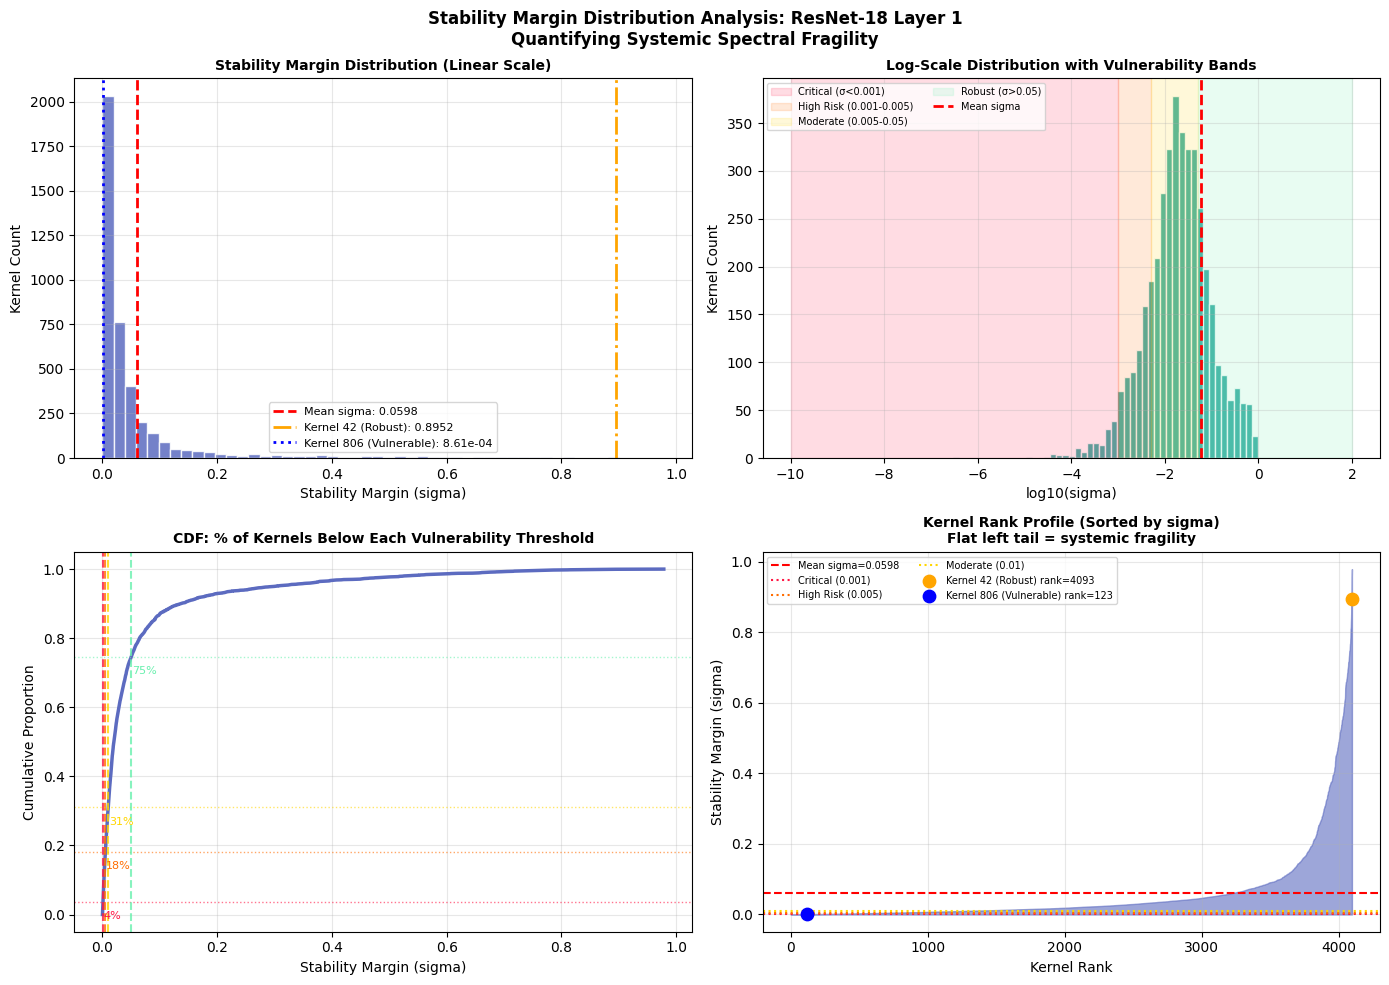

Saved: SigmaDistributionAnalysis.png


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sharedfunctions import (loadKernels, computeSigma, computeMagnitudeResponse,
                              IDXROBUST, IDXVULNERABLE, GRIDSIZE, NTHRESH, CSVPATH)

# ============================================================
# Load kernels and compute sigmas
# ============================================================
kernels = loadKernels(CSVPATH)

print("Computing sigmas for all 4096 kernels (this will take a few minutes)...")
sigmas = np.array([computeSigma(k) for k in kernels])
print("Done.")

meanSigma = np.mean(sigmas)
thresholds = [0.001, 0.005, 0.01, 0.05]

# ============================================================
# Print summary
# ============================================================
print(f"\n  Total kernels: {len(sigmas)}")
print(f"  Mean sigma:    {meanSigma:.6f}")
print(f"  Min sigma:     {sigmas.min():.2e}  (Kernel {np.argmin(sigmas)})")
print(f"  Max sigma:     {sigmas.max():.6f}  (Kernel {np.argmax(sigmas)})")

print(f"\n  Vulnerability Threshold Analysis:")
for thr in thresholds:
    n = np.sum(sigmas < thr)
    print(f"    sigma < {thr:.3f}: {n:4d} / {len(sigmas)} kernels  ({100*n/len(sigmas):.1f}%)")

# ============================================================
# Vulnerability band classification
# ============================================================
bands = [
    ('Critical',  0.000, 0.001),
    ('High Risk', 0.001, 0.005),
    ('Moderate',  0.005, 0.050),
    ('Robust',    0.050, np.inf),
]
bandColors = ['#ff1744', '#ff6d00', '#ffd600', '#69f0ae']

print(f"\n  Full band classification:")
print(f"  {'Band':<12} {'Range':<22} {'Count':>6}  {'%':>6}")
print("  " + "-"*50)
for (name, lo, hi), col in zip(bands, bandColors):
    count = np.sum((sigmas >= lo) & (sigmas < hi))
    pct = 100 * count / len(sigmas)
    hi_str = f"{hi:.3f}" if hi != np.inf else "∞"
    print(f"  {name:<12} [{lo:.3f}, {hi_str})        {count:>6}  {pct:>5.1f}%")

# ============================================================
# Figure: four-panel distribution analysis
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Stability Margin Distribution Analysis: ResNet-18 Layer 1\n"
             "Quantifying Systemic Spectral Fragility",
             fontsize=12, fontweight='bold')

# Top left: linear histogram
ax = axes[0, 0]
ax.hist(sigmas, bins=50, color='#5c6bc0', edgecolor='white', alpha=0.85)
ax.axvline(meanSigma, color='red', linewidth=2, linestyle='--',
           label=f'Mean sigma: {meanSigma:.4f}')
ax.axvline(sigmas[IDXROBUST], color='orange', linewidth=2, linestyle='-.',
           label=f'Kernel {IDXROBUST} (Robust): {sigmas[IDXROBUST]:.4f}')
ax.axvline(sigmas[IDXVULNERABLE], color='blue', linewidth=2, linestyle=':',
           label=f'Kernel {IDXVULNERABLE} (Vulnerable): {sigmas[IDXVULNERABLE]:.2e}')
ax.set_title("Stability Margin Distribution (Linear Scale)",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Stability Margin (sigma)", fontsize=10)
ax.set_ylabel("Kernel Count", fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Top right: log scale with band shading
ax = axes[0, 1]
logSigmas = np.log10(sigmas + 1e-10)
ax.hist(logSigmas, bins=50, color='#26a69a', edgecolor='white', alpha=0.85)
bandLabels = ['Critical (σ<0.001)', 'High Risk (0.001-0.005)',
              'Moderate (0.005-0.05)', 'Robust (σ>0.05)']
edges = [-10, -3, np.log10(0.005), np.log10(0.05), 2]
for i in range(4):
    ax.axvspan(edges[i], edges[i+1], alpha=0.15,
               color=bandColors[i], label=bandLabels[i])
ax.axvline(np.log10(meanSigma + 1e-10), color='red', linewidth=2,
           linestyle='--', label='Mean sigma')
ax.set_title("Log-Scale Distribution with Vulnerability Bands",
             fontsize=10, fontweight='bold')
ax.set_xlabel("log10(sigma)", fontsize=10)
ax.set_ylabel("Kernel Count", fontsize=10)
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# Bottom left: CDF
ax = axes[1, 0]
sortedSigmas = np.sort(sigmas)
cdf = np.arange(1, len(sortedSigmas) + 1) / len(sortedSigmas)
ax.plot(sortedSigmas, cdf, color='#5c6bc0', linewidth=2.5)
for thr, col in zip([0.001, 0.005, 0.01, 0.05], bandColors):
    pct = np.mean(sigmas < thr)
    ax.axvline(thr, color=col, linewidth=1.5, linestyle='--', alpha=0.8)
    ax.axhline(pct, color=col, linewidth=1.0, linestyle=':', alpha=0.6)
    ax.text(thr + 0.001, pct - 0.05, f'{pct*100:.0f}%', fontsize=8, color=col)
ax.set_title("CDF: % of Kernels Below Each Vulnerability Threshold",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Stability Margin (sigma)", fontsize=10)
ax.set_ylabel("Cumulative Proportion", fontsize=10)
ax.grid(True, alpha=0.3)

# Bottom right: rank profile
ax = axes[1, 1]
ax.fill_between(np.arange(len(sortedSigmas)), sortedSigmas,
                alpha=0.6, color='#5c6bc0')
ax.axhline(meanSigma, color='red', linewidth=1.5, linestyle='--',
           label=f'Mean sigma={meanSigma:.4f}')
for thr, col, lbl in zip(
        [0.001, 0.005, 0.01],
        ['#ff1744', '#ff6d00', '#ffd600'],
        ['Critical (0.001)', 'High Risk (0.005)', 'Moderate (0.01)']):
    ax.axhline(thr, color=col, linewidth=1.5, linestyle=':', label=lbl)

rankRob = int(np.searchsorted(sortedSigmas, sigmas[IDXROBUST]))
rankVul = int(np.searchsorted(sortedSigmas, sigmas[IDXVULNERABLE]))
ax.scatter([rankRob], [sigmas[IDXROBUST]], color='orange', s=80, zorder=5,
           label=f'Kernel {IDXROBUST} (Robust) rank={rankRob}')
ax.scatter([rankVul], [sigmas[IDXVULNERABLE]], color='blue', s=80, zorder=5,
           label=f'Kernel {IDXVULNERABLE} (Vulnerable) rank={rankVul}')
ax.set_title("Kernel Rank Profile (Sorted by sigma)\nFlat left tail = systemic fragility",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Kernel Rank", fontsize=10)
ax.set_ylabel("Stability Margin (sigma)", fontsize=10)
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("SigmaDistributionAnalysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: SigmaDistributionAnalysis.png")